# 08 - Final Evaluation and Prediction

## Objective

This notebook brings together the final experimental results and demonstrates prediction on unseen data.

The final proposed pipeline uses:

**Preprocessing → Autoencoder 90% feature selection → K-Means clustering (K=2) → tuned Random Forest**

The notebook also compares the main experiments and reports Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrix and classification report.

> The dataset is synthetic. Model predictions are experimental results on this dataset and are not clinical diagnoses.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from xgboost import XGBClassifier

np.random.seed(42)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("../data/diabetes_dataset.csv")

print("Dataset shape:", df.shape)


Dataset shape: (100000, 31)


In [3]:
# Define target and exclude leakage-prone feature
target_column = "diagnosed_diabetes"
leakage_columns = ["diabetes_stage"]

X = df.drop(columns=[target_column] + leakage_columns)
y = df[target_column].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Input features:", X.shape[1])


Training samples: 80000
Testing samples: 20000
Input features: 29


In [4]:
# Preprocessing
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (80000, 47)
Processed testing shape: (20000, 47)


## Recreate the 90% Autoencoder Feature Selection

In [5]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, 12, 32),
    activation="relu",
    solver="adam",
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=5,
    random_state=42
)

autoencoder.fit(X_train_processed, X_train_processed)

encoder_weights = autoencoder.coefs_[0]
raw_importance = np.sum(np.abs(encoder_weights), axis=1)
importance = raw_importance / raw_importance.sum()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feature_importance["Cumulative_Percent"] = (
    feature_importance["Importance"].cumsum() * 100
)

first_index = feature_importance.index[
    feature_importance["Cumulative_Percent"] >= 90
][0]

selected_features = feature_importance.loc[:first_index, "Feature"].tolist()
selected_indices = [list(feature_names).index(f) for f in selected_features]

X_train_selected = X_train_processed[:, selected_indices]
X_test_selected = X_test_processed[:, selected_indices]

print("90% selected features:", len(selected_features))
print(
    "Actual cumulative importance:",
    round(feature_importance.loc[first_index, "Cumulative_Percent"], 4),
    "%"
)


90% selected features: 36
Actual cumulative importance: 90.0169 %


## Recreate K-Means (K=2)

K=2 was selected in the previous clustering notebook because it had the highest silhouette score among K=2..6.


In [6]:
best_k = 2

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans_final.fit_predict(X_train_selected)
test_clusters = kmeans_final.predict(X_test_selected)

X_train_final = np.column_stack([
    X_train_selected,
    train_clusters
])

X_test_final = np.column_stack([
    X_test_selected,
    test_clusters
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)
print("K:", best_k)


Final training shape: (80000, 37)
Final testing shape: (20000, 37)
K: 2


## Final Tuned Random Forest

The tuned Random Forest parameters obtained from the previous notebook are used here for the final proposed model.


In [7]:
rf_final = RandomForestClassifier(
    n_estimators=266,
    max_depth=8,
    max_features=None,
    min_samples_leaf=3,
    min_samples_split=9,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train)

rf_final_pred = rf_final.predict(X_test_final)
rf_final_prob = rf_final.predict_proba(X_test_final)[:, 1]

final_rf_results = {
    "Model": "Tuned Random Forest - 90% + Cluster",
    "Accuracy": accuracy_score(y_test, rf_final_pred),
    "Precision": precision_score(y_test, rf_final_pred),
    "Recall": recall_score(y_test, rf_final_pred),
    "F1-Score": f1_score(y_test, rf_final_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_final_prob)
}

pd.DataFrame([final_rf_results]).round(4)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest - 90% + Cluster,0.9102,0.9992,0.851,0.9192,0.9416


## Final Classification Report

In [8]:
print(
    classification_report(
        y_test,
        rf_final_pred,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

 No Diabetes       0.82      1.00      0.90      8000
    Diabetes       1.00      0.85      0.92     12000

    accuracy                           0.91     20000
   macro avg       0.91      0.93      0.91     20000
weighted avg       0.93      0.91      0.91     20000



## Final Confusion Matrix

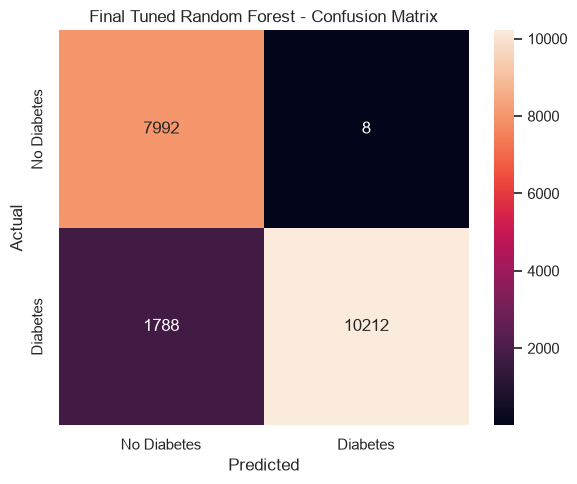

In [9]:
cm = confusion_matrix(y_test, rf_final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Final Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## Final ROC Curve

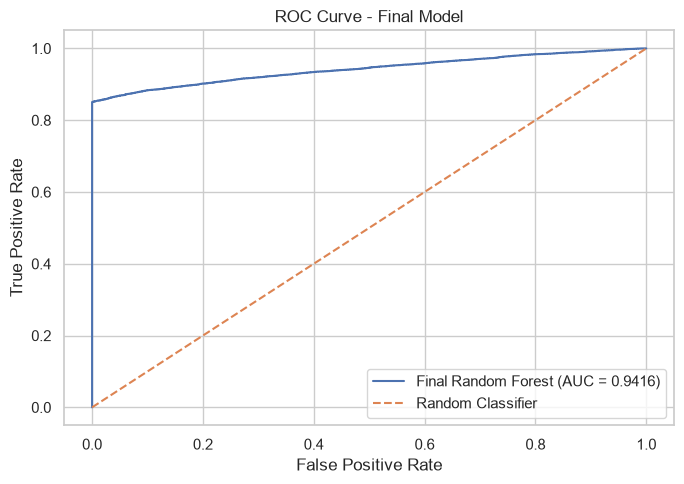

In [10]:
fpr, tpr, _ = roc_curve(y_test, rf_final_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Final Random Forest (AUC = {final_rf_results['ROC-AUC']:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.tight_layout()
plt.show()


## Overall Model Comparison

The table below combines the actual results obtained during the project experiments.

`Baseline` = all leakage-free features.

`Autoencoder 90%` = 36 selected processed features.

`Autoencoder 90% + Cluster` = 36 selected features plus the K-Means cluster.

`Tuned` = Autoencoder 90% + Cluster with tuned model parameters.


In [11]:
overall_results = pd.DataFrame([
    ["Baseline", "Random Forest", 0.9198, 0.9994, 0.8668, 0.9284, 0.9424],
    ["Baseline", "XGBoost",       0.9193, 0.9988, 0.8666, 0.9280, 0.9423],
    ["Autoencoder 85%", "Random Forest", 0.6156, np.nan, np.nan, 0.7102, 0.6375],
    ["Autoencoder 85%", "XGBoost",       0.6266, np.nan, np.nan, 0.7226, 0.6481],
    ["Autoencoder 90%", "Random Forest", 0.9092, 0.9967, 0.8515, 0.9184, 0.9403],
    ["Autoencoder 90%", "XGBoost",       0.9098, 0.9966, 0.8527, 0.9190, 0.9385],
    ["Autoencoder 91.05%", "Random Forest", 0.9098, np.nan, np.nan, 0.9189, 0.9396],
    ["Autoencoder 91.05%", "XGBoost",       0.9098, np.nan, np.nan, 0.9189, 0.9396],
    ["90% + Cluster", "Random Forest", 0.9092, 0.9961, 0.8519, 0.9184, 0.9406],
    ["90% + Cluster", "XGBoost",       0.9100, 0.9965, 0.8531, 0.9192, 0.9391],
    ["Tuned 90% + Cluster", "Random Forest", 0.9102, 0.9992, 0.8510, 0.9192, 0.9416],
    ["Tuned 90% + Cluster", "XGBoost",       0.9102, 0.9983, 0.8518, 0.9193, 0.9404]
], columns=[
    "Stage", "Model", "Accuracy", "Precision",
    "Recall", "F1-Score", "ROC-AUC"
])

overall_results.round(4)


,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Random Forest,0.9198,0.9994,0.8668,0.9284,0.9424
1,Baseline,XGBoost,0.9193,0.9988,0.8666,0.9280,0.9423
2,Autoencoder 85%,Random Forest,0.6156,NaN,NaN,0.7102,0.6375
3,Autoencoder 85%,XGBoost,0.6266,NaN,NaN,0.7226,0.6481
4,Autoencoder 90%,Random Forest,0.9092,0.9967,0.8515,0.9184,0.9403
5,Autoencoder 90%,XGBoost,0.9098,0.9966,0.8527,0.9190,0.9385
6,Autoencoder 91.05%,Random Forest,0.9098,NaN,NaN,0.9189,0.9396
7,Autoencoder 91.05%,XGBoost,0.9098,NaN,NaN,0.9189,0.9396
8,90% + Cluster,Random Forest,0.9092,0.9961,0.8519,0.9184,0.9406
9,90% + Cluster,XGBoost,0.9100,0.9965,0.8531,0.9192,0.9391


### Final interpretation

The original leakage-free Random Forest baseline recorded the highest ROC-AUC among the experiments completed so far (0.9424). The proposed Autoencoder + K-Means + tuning pipeline remained close to the baseline, with the tuned Random Forest reaching 0.9416 ROC-AUC.

Therefore, the experiments show that the additional feature-selection and clustering stages did **not** provide a substantial improvement on this synthetic dataset. This result is reported as an experimental finding rather than forcing the proposed approach to appear better.


## Final Unseen-Data Demonstration

The following example uses one row from the held-out test set. Because this row was not used to train the final model, it is an unseen test example.

For a real application, a new patient's input would pass through the same preprocessing, feature-selection, clustering and final model pipeline.


In [12]:
# Take one unseen test example
sample_input = X_test.iloc[[0]].copy()
actual_label = int(y_test.iloc[0])

# Same transformation used during training
sample_processed = preprocessor.transform(sample_input)

# Select the 90% Autoencoder-selected features
sample_selected = sample_processed[:, selected_indices]

# Assign the new/unseen record to a cluster
sample_cluster = kmeans_final.predict(sample_selected)

# Add cluster information
sample_final = np.column_stack([
    sample_selected,
    sample_cluster
])

# Final prediction
sample_prediction = int(rf_final.predict(sample_final)[0])
sample_probability = float(rf_final.predict_proba(sample_final)[0, 1])

print("Actual label:", actual_label)
print("Predicted label:", sample_prediction)
print("Predicted probability of diabetes:", round(sample_probability, 4))

if sample_prediction == 1:
    print("Prediction: Diabetes")
else:
    print("Prediction: No Diabetes")


Actual label: 0
Predicted label: 0
Predicted probability of diabetes: 0.1851
Prediction: No Diabetes


## Final Project Summary

The completed workflow is:

**Dataset → EDA → Leakage Check → Preprocessing → Baseline RF/XGBoost → Autoencoder Feature Selection (85%, 90%, 91.05%) → K-Means Clustering → Hyperparameter Tuning → Final Evaluation → Unseen Prediction**

The study demonstrates the full machine-learning workflow and experimentally measures whether the proposed feature-selection and clustering techniques improve the baseline.

Because the dataset is synthetic, the results should not be interpreted as clinical validation.
